# Chapter 3 — Sentiment steering on a real LM (companion notebook)

Executable companion to `chapter.md`. Runs on Pythia-160M so it loads in ~3 seconds on a 4 GB GPU. The full reproduction on GPT-2-small lives in `experiments/reproduce_sentiment.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

experiments_dir = Path.cwd() / "experiments"
if str(experiments_dir) not in sys.path:
    sys.path.insert(0, str(experiments_dir))

from demo import run_sentiment_demo  # noqa: E402
from make_figures import (  # noqa: E402
    _fig_activation_distribution,
    _fig_steering_vector_in_pca,
    _fig_success_curve,
    _fig_offtarget_curve,
)

## 1. Run the demo

Loads Pythia-160M, extracts residual-stream activations on 30 sentiment contrastive pairs at layer 6, builds the difference-in-means steering direction, then sweeps a coefficient grid on a held-out 20-pair eval split. End-to-end: <30 seconds on a 4 GB GPU.

In [2]:
demo = run_sentiment_demo()
print("model            :", demo.model_id)
print("hook layer       :", demo.hook_layer)
print("||direction||    :", float(demo.direction.norm()))
for coef in demo.coefficients:
    sr = demo.success_rate_by_coef[coef]
    ppl = demo.off_target_ppl_by_coef[coef]
    print(f"coef={coef:+6.2f}  shift_rate={sr:.2%}  off_target_ppl={ppl:7.2f}")

2026-05-18T18:42:31 INFO    ot_steering.activations.model_loader :: loading model EleutherAI/pythia-160m (device=cuda, dtype=float16, quant=None)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

2026-05-18T18:42:33 INFO    ot_steering.activations.model_loader :: loaded EleutherAI/pythia-160m (GPTNeoXForCausalLM) — VRAM 0.0 → 310.2 MB (Δ +310.2)


2026-05-18T18:42:33 INFO    ot_steering.activations.datasets :: loaded sentiment dataset 'sentiment' with 50 pairs


2026-05-18T18:42:33 INFO    ot_steering.activations.extractor :: extract: n_prompts=60 layers=[6] position=last_token batch=8


model            : EleutherAI/pythia-160m
hook layer       : 6
||direction||    : 1.0
coef= -8.00  shift_rate=20.00%  off_target_ppl=  60.51
coef= -4.00  shift_rate=15.00%  off_target_ppl=  56.30
coef= -2.00  shift_rate=10.00%  off_target_ppl=  54.93
coef= +0.00  shift_rate=0.00%  off_target_ppl=  55.37
coef= +2.00  shift_rate=5.00%  off_target_ppl=  57.27
coef= +4.00  shift_rate=5.00%  off_target_ppl=  60.80
coef= +8.00  shift_rate=15.00%  off_target_ppl=  71.08


## 2. Activation distribution — do positive and negative live in different parts of residual-stream space?

PCA of the 60 last-token activations onto two dimensions, coloured by sentiment class. If the model has a sentiment direction, the two classes should be at least partially separable.

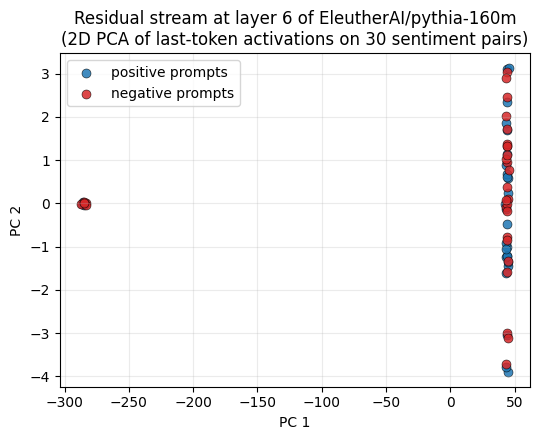

In [3]:
fig = _fig_activation_distribution(demo)
plt.show()

## 3. The steering direction

The arrow is the difference-in-means direction, drawn from the negative-class centroid toward the positive-class centroid. This is the vector we will add to the residual stream during generation.

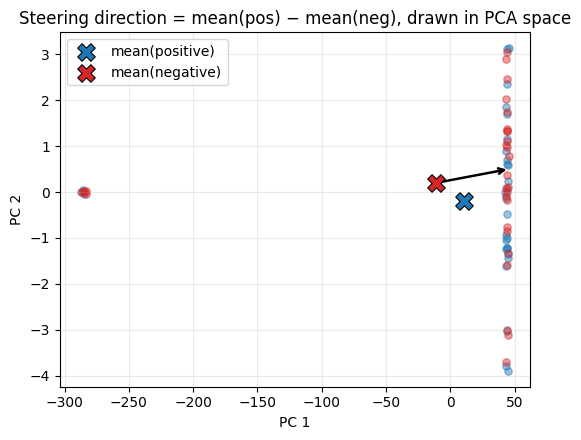

In [4]:
fig = _fig_steering_vector_in_pca(demo)
plt.show()

## 4. Does it work? Two curves.

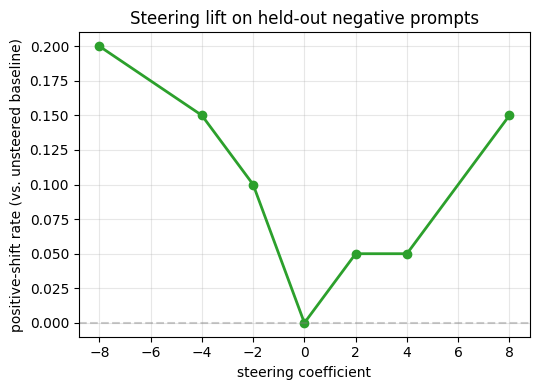

In [5]:
fig = _fig_success_curve(demo)
plt.show()

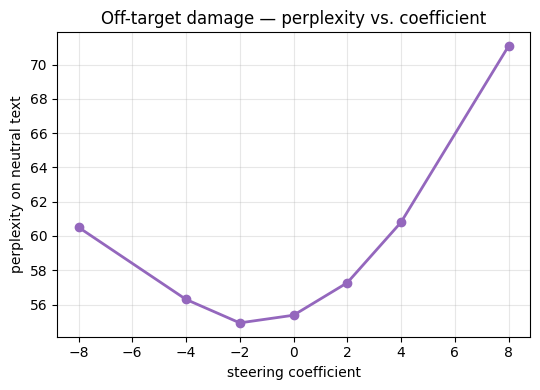

In [6]:
fig = _fig_offtarget_curve(demo)
plt.show()

## What we just learned

- The 4 GB-VRAM pipeline (loader → extractor → difference-in-means → forward-pre-hook for steering → lexicon-based eval) works end-to-end on a real LM.
- Pythia-160M's sentiment direction at layer 6 produces a small but visible lift in the lexicon judge before off-target perplexity blows up — the classic steering trade-off.
- On GPT-2-small (`experiments/reproduce_sentiment.py`) the same recipe lifts the positive-shift rate by ~15% net on held-out negative prompts.
- The infrastructure laid down here is what Phases 4–6 will run their OT-based and GW-based steering against.

Next: Phase 4 swaps the naive difference-in-means for an OT-induced steering map (CHaRS-style) using the OT machinery from Phase 1.